### Auto MPG  

Predict fuel efficiency from car specs

Built a Linear Regression model to predict vehicle fuel efficiency (MPG) using the UCI Auto MPG dataset. Performed data cleaning, feature engineering, and model evaluation using R² and MSE. Achieved strong predictive performance and analyzed feature coefficients to interpret the impact of engine size, weight, and model year on fuel economy.

| Attribute      | Type                  | Description                       |                                        |
| -------------- | --------------------- | --------------------------------- | -------------------------------------- |
| `mpg`          | Continuous            | Miles per gallon (target)         |                                        |
| `cylinders`    | Integer / Categorical | Number of engine cylinders        |                                        |
| `displacement` | Continuous            | Engine displacement               |                                        |
| `horsepower`   | Continuous            | Engine power (has missing values) |                                        |
| `weight`       | Continuous            | Vehicle weight                    |                                        |
| `acceleration` | Continuous            | Time to accelerate (0–60 mph)     |                                        |
| `model_year`   | Integer               | Model year of the car             |                                        |
| `origin`       | Integer / Categorical | Region of origin                  |                                        |
| `car_name`     | Categorical           | Vehicle name (unique for each)    | ([UCI Machine Learning Repository][1]) |

[1]: https://archive.ics.uci.edu/ml/datasets/auto%2Bmpg?utm_source=chatgpt.com "UCI Machine Learning Repository"


In [1]:

import pandas as pd
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


In [2]:

url = "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

columns = ['mpg','cylinders','displacement','horsepower','weight', 'acceleration','model year','origin','car name']

df = pd.read_csv(url, names=columns, sep=r'\s+', na_values='?')



    sep=r'\s+'	Uses regex separator: split on one or more whitespace characters

    na_values='?'	Treats '?' as a missing value (NaN)


In [6]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [4]:
#  Drop rows with missing values

df.dropna(inplace=True)


In [5]:
df[:15]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
5,15.0,8,429.0,198.0,4341.0,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220.0,4354.0,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215.0,4312.0,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225.0,4425.0,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190.0,3850.0,8.5,70,1,amc ambassador dpl


In [8]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model year        int64
origin            int64
car name         object
dtype: object

In [7]:
# Convert horsepower to float (it was loaded as object due to '?')

df['horsepower'] = df['horsepower'].astype(float)


In [9]:
#  Drop non-numeric 'car name'

df.drop(columns=['car name'], inplace=True)


In [10]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1


In [11]:
#  Define features and target

X = df.drop(columns=['mpg'])  # all features except target
y = df['mpg']                 # target


In [12]:
X

,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,8,307.0,130.0,3504.0,12.0,70,1
1,8,350.0,165.0,3693.0,11.5,70,1
2,8,318.0,150.0,3436.0,11.0,70,1
3,8,304.0,150.0,3433.0,12.0,70,1
4,8,302.0,140.0,3449.0,10.5,70,1
...,...,...,...,...,...,...,...
393,4,140.0,86.0,2790.0,15.6,82,1
394,4,97.0,52.0,2130.0,24.6,82,2
395,4,135.0,84.0,2295.0,11.6,82,1
396,4,120.0,79.0,2625.0,18.6,82,1


In [13]:
y

0      18.0
1      15.0
2      18.0
3      16.0
4      17.0
       ... 
393    27.0
394    44.0
395    32.0
396    28.0
397    31.0
Name: mpg, Length: 392, dtype: float64

In [14]:
# Feature scaling (optional but helps with regularized models)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [16]:
#  Train-test split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [17]:
# Train Linear Regression model

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [18]:
#  Predict and evaluate

y_pred = model.predict(X_test)

y_pred

array([25.84156153, 26.03674454, 34.50601837, 24.89553187, 28.42598707,
       30.56138237,  8.58694262, 30.7218562 , 20.55678574, 28.64682346,
       12.61214902, 25.2643465 , 16.77369622, 29.68019379, 21.82299683,
       29.24834035, 20.39502626, 33.38385417, 26.67772934, 29.95149498,
       18.93820309, 34.50905163, 35.48745148, 14.89405823, 28.45593435,
       25.63054631, 21.02578033, 16.17903858, 28.69605142, 24.09256378,
       13.39025838, 23.44947094, 20.79944762, 31.89302231, 12.28040099,
       36.22266955, 10.8636647 , 24.36542068, 11.44089858,  7.13672588,
       12.8573181 , 27.56118055, 34.72959156, 26.38589426, 11.98975421,
        9.7978054 , 17.6085252 , 31.37733687, 24.35162554, 30.20405732,
       11.90151257, 26.51654159, 23.12231154, 35.1356023 , 28.26003717,
       17.78388638, 20.273919  , 22.70560675, 22.71178336, 25.99895526,
        8.48482756, 22.69686893, 25.76229967, 23.34794704, 29.95814981,
       28.72694968, 25.73473703, 29.42872474, 21.73843531, 10.07

In [19]:
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R² Score: 0.7901500386760343
RMSE: 3.2727457003009577


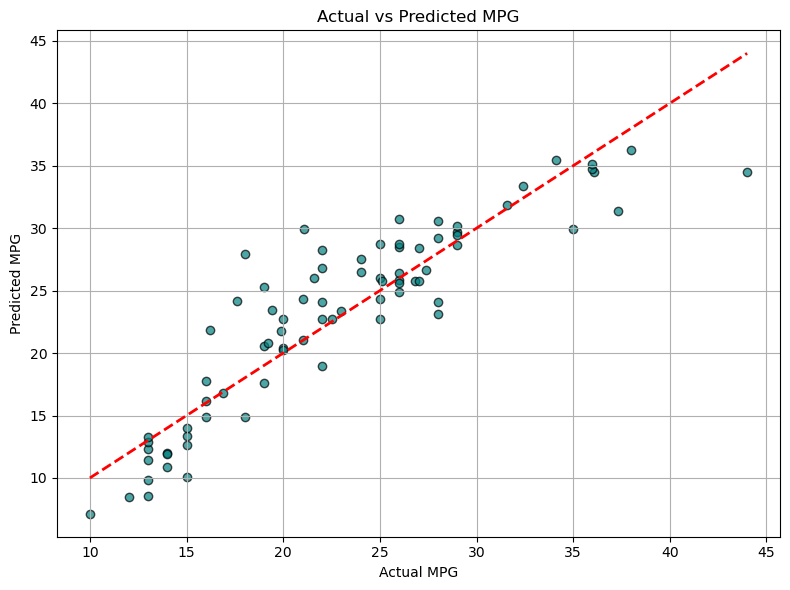

In [20]:
import matplotlib.pyplot as plt

# Scatter plot: Actual vs Predicted

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title('Actual vs Predicted MPG')
plt.grid(True)
plt.tight_layout()
plt.show()


In [21]:
# === Predict MPG for a new car ===
new_data = {
    'cylinders': 4,
    'displacement': 120.0,
    'horsepower': 88.0,
    'weight': 2500.0,
    'acceleration': 15.0,
    'model year': 82,
    'origin': 1
}

new_df = pd.DataFrame([new_data])
new_scaled = scaler.transform(new_df)
predicted_mpg = model.predict(new_scaled)

print("\n New Car Prediction:")
print("Input Features:", new_data)
print("Predicted MPG:", round(predicted_mpg[0], 2))



 New Car Prediction:
Input Features: {'cylinders': 4, 'displacement': 120.0, 'horsepower': 88.0, 'weight': 2500.0, 'acceleration': 15.0, 'model year': 82, 'origin': 1}
Predicted MPG: 29.84
